##### Imports

In [111]:
import numpy as np
import matplotlib.pyplot as plt
import torch

import torchvision.datasets
from torchvision import transforms

import os
from tqdm import tqdm

##### Data sources

In [112]:
pets_path_train = './OxfordPets/train'
pets_path_test = './OxfordPets/test'
pets_train_orig = torchvision.datasets.OxfordIIITPet(root=pets_path_train, split='trainval', target_types='category', download=True)
pets_test_orig = torchvision.datasets.OxfordIIITPet(root=pets_path_test, split='test', target_types='category', download=True)

In [113]:
class_names = pets_train_orig.classes
len(class_names)

37

In [114]:
class_names

['Abyssinian',
 'American Bulldog',
 'American Pit Bull Terrier',
 'Basset Hound',
 'Beagle',
 'Bengal',
 'Birman',
 'Bombay',
 'Boxer',
 'British Shorthair',
 'Chihuahua',
 'Egyptian Mau',
 'English Cocker Spaniel',
 'English Setter',
 'German Shorthaired',
 'Great Pyrenees',
 'Havanese',
 'Japanese Chin',
 'Keeshond',
 'Leonberger',
 'Maine Coon',
 'Miniature Pinscher',
 'Newfoundland',
 'Persian',
 'Pomeranian',
 'Pug',
 'Ragdoll',
 'Russian Blue',
 'Saint Bernard',
 'Samoyed',
 'Scottish Terrier',
 'Shiba Inu',
 'Siamese',
 'Sphynx',
 'Staffordshire Bull Terrier',
 'Wheaten Terrier',
 'Yorkshire Terrier']

In [115]:
pets_train_orig, pets_test_orig

(Dataset OxfordIIITPet
     Number of datapoints: 3680
     Root location: ./OxfordPets/train,
 Dataset OxfordIIITPet
     Number of datapoints: 3669
     Root location: ./OxfordPets/test)

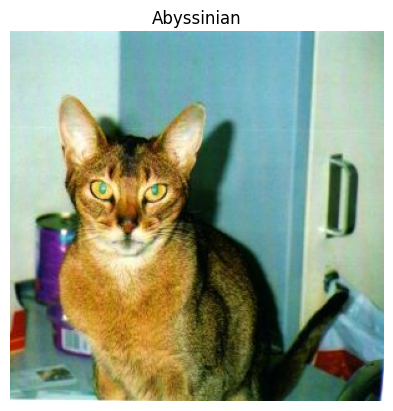

In [116]:
(train_pets_input, train_pets_target) = pets_train_orig[20]
plt.imshow(train_pets_input)
# plt.imshow(train_pets_input.permute(1,2,0).numpy())
plt.title(class_names[train_pets_target])
plt.axis('off')
plt.show()

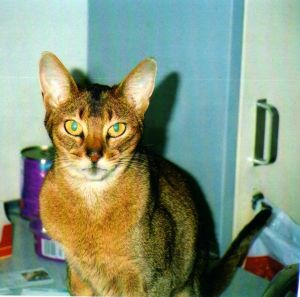

In [117]:
train_pets_input

In [118]:
train_pets_target

0

In [119]:
len(pets_train_orig), len(pets_test_orig)

(3680, 3669)

In [120]:
# Create a dataset wrapper that allows us to perform custom image augmentations
# on both the target and label (segmentation mask) images.
#
# These custom image augmentations are needed since we want to perform
# transforms such as:
# 1. Random horizontal flip
# 2. Image resize
#
# and these operations need to be applied consistently to both the input
# image as well as the segmentation mask.
class OxfordIIITPetsAugmented(torchvision.datasets.OxfordIIITPet):
    def __init__(
        self,
        root: str,
        split: str,
        # target_types="segmentation",
        target_types="category",
        download=False,
        pre_transform=None,
        post_transform=None,
        pre_target_transform=None,
        post_target_transform=None,
        common_transform=None,
    ):
        super().__init__(
            root=root,
            split=split,
            target_types=target_types,
            download=download,
            transform=pre_transform,
            # target_transform=pre_target_transform,
        )
        self.post_transform = post_transform
        # self.post_target_transform = post_target_transform
        self.common_transform = common_transform

    def __len__(self):
        return super().__len__()

    def __getitem__(self, idx):
        (input, target) = super().__getitem__(idx)
        
        # Common transforms are performed on both the input and the labels
        # by creating a 4 channel image and running the transform on both.
        # Then the segmentation mask (4th channel) is separated out.
        if self.common_transform is not None:
            # both = torch.cat([input, target], dim=0)
            # both = self.common_transform(both)
            # (input, target) = torch.split(both, 3, dim=0)
            input = self.common_transform(input)
        # end if
        
        if self.post_transform is not None:
            input = self.post_transform(input)
        # if self.post_target_transform is not None:
        #     target = self.post_target_transform(target)

        return (input, target)

In [121]:
def args_to_dict(**kwargs):
    return kwargs

transform_dict = args_to_dict(
    pre_transform=transforms.ToTensor(),
    pre_target_transform=transforms.ToTensor(),
    common_transform=transforms.Compose([
        # ToDevice(get_device()),
        # transforms.Resize((128, 128), interpolation=T.InterpolationMode.NEAREST),
        # transforms.RandomResizedCrop(224),
        # transforms.Resize((224, 224), interpolation=T.InterpolationMode.NEAREST),
        transforms.Resize(224, interpolation=transforms.InterpolationMode.NEAREST),
        transforms.RandomCrop(224),
        # Random Horizontal Flip as data augmentation.
        transforms.RandomHorizontalFlip(p=0.5),
    ]),
    # post_transform=transforms.Compose([
        # Color Jitter as data augmentation.
        # transforms.ColorJitter(contrast=0.3),
    # ]),
    # post_target_transform=T.Compose([
    #     # T.Lambda(tensor_trimap),
    # ]),
)

In [122]:
pets_train = OxfordIIITPetsAugmented(
    root=pets_path_train,
    split="trainval",
    # target_types="segmentation",
    target_types="category",
    download=False,
    **transform_dict,
)

In [123]:
pets_test = OxfordIIITPetsAugmented(
    root=pets_path_test,
    split="test",
    # target_types="segmentation",
    target_types="category",
    download=False,
    **transform_dict,
)

In [124]:
pets_train, pets_test

(Dataset OxfordIIITPetsAugmented
     Number of datapoints: 3680
     Root location: ./OxfordPets/train
     StandardTransform
 Transform: ToTensor(),
 Dataset OxfordIIITPetsAugmented
     Number of datapoints: 3669
     Root location: ./OxfordPets/test
     StandardTransform
 Transform: ToTensor())

In [125]:
pets_train_loader = torch.utils.data.DataLoader(
    pets_train,
    # batch_size=64,
    batch_size=16,
    shuffle=True,
)

In [126]:
pets_test_loader = torch.utils.data.DataLoader(
    pets_test,
    batch_size=21,
    shuffle=True,
)

In [127]:
(train_pets_inputs, train_pets_targets) = next(iter(pets_train_loader))

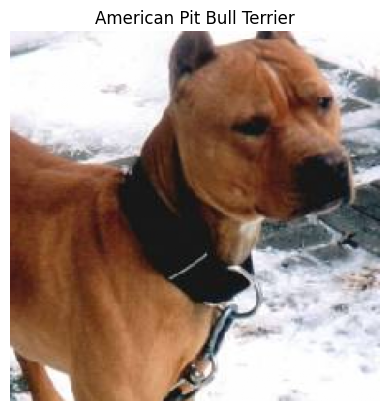

In [128]:
plt.imshow(train_pets_inputs[0].permute(1,2,0).numpy())
plt.axis('off')
plt.title(class_names[train_pets_targets[0]])
plt.show()

In [129]:
train_pets_targets

tensor([ 2,  4, 12, 19, 15, 20, 27,  6, 29,  6,  3,  1,  8, 28,  6, 27])

In [130]:
def show_images(input_tensor, title=''):
    image = input_tensor.permute(1,2,0).numpy()
    plt.imshow(image)
    plt.title(title)
    plt.axis('off')
    plt.show()
    plt.pause(0.01)

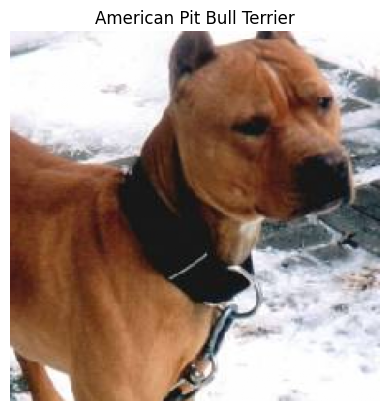

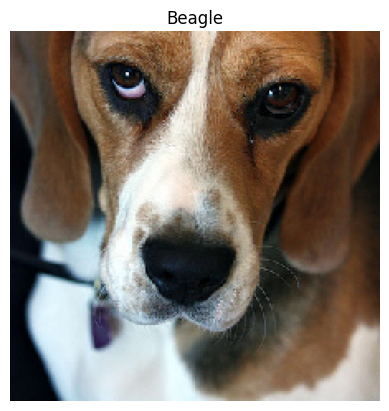

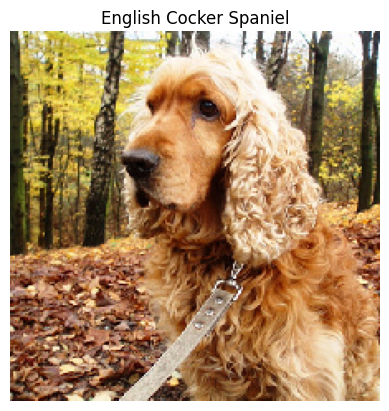

In [131]:
for i in range(len(train_pets_inputs)//5):
    show_images(train_pets_inputs[i], title=class_names[train_pets_targets[i]])

##### Save/load functions

In [132]:
def getdevice():
    if torch.cuda.is_available():
        return 'cuda'
    else:
        return 'cpu'

def savemodel(model, path):
    torch.save(model.state_dict(), path)

# def saveall(model, optimizer, loss, epoch, path):
def saveall(model, optimizer, epoch, path):
    torch.save({
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        # 'loss': loss,
        'epoch': epoch
    }, path)

def loadmodel(model, path):
    # return model.load_state_dict(torch.load(path, map_location=getdevice()))
    # return model.load_state_dict(torch.load(path, weights_only=True))
    model.load_state_dict(torch.load(path, weights_only=True))

def loadall(model, optimizer, path):
    cp = torch.load(path, weights_only=True)
    model.load_state_dict(cp['model_state_dict'])
    optimizer.load_state_dict(cp['optimizer_state_dict'])
    # return cp['loss'], cp['epoch']
    return cp['epoch']


##### Neural net

In [133]:
class PetsNet(torch.nn.Module):
    def __init__(self):
        super(PetsNet, self).__init__()

        # pre-normalization
        self.bn0 = torch.nn.BatchNorm2d(num_features=3)

        # layer 1: 224x224x3
        self.conv1 = torch.nn.Conv2d(in_channels=3, out_channels=4, kernel_size=3, padding=1)
        self.act1 = torch.nn.ReLU()
        self.bn1 = torch.nn.BatchNorm2d(num_features=4)
        self.mp1 = torch.nn.MaxPool2d(kernel_size=2, stride=2)

        # layer 2: 112x112x4
        self.conv2 = torch.nn.Conv2d(in_channels=4, out_channels=8, kernel_size=3, padding=1)
        self.act2 = torch.nn.ReLU()
        self.bn2 = torch.nn.BatchNorm2d(num_features=8)
        self.mp2 = torch.nn.MaxPool2d(kernel_size=2, stride=2)

        # layer 3: 56x56x8
        self.conv3 = torch.nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3, padding=1)
        self.act3 = torch.nn.ReLU()
        self.bn3 = torch.nn.BatchNorm2d(num_features=16)
        self.mp3 = torch.nn.MaxPool2d(kernel_size=2, stride=2)

        # layer 4: 28x28x16
        self.conv4 = torch.nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.act4 = torch.nn.ReLU()
        self.bn4 = torch.nn.BatchNorm2d(num_features=32)
        self.mp4 = torch.nn.MaxPool2d(kernel_size=2, stride=2)

        # layer 5: 14x14x32
        self.conv5 = torch.nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.act5 = torch.nn.ReLU()
        self.bn5 = torch.nn.BatchNorm2d(num_features=64)
        self.mp5 = torch.nn.MaxPool2d(kernel_size=2, stride=2)

        # layer 6: 7x7x64
        self.fc1 = torch.nn.Linear(7*7*64, 512)
        self.act6 = torch.nn.Tanh()
        self.bn6 = torch.nn.BatchNorm1d(num_features=512)

        # layer 7: 1x512
        self.fc2 = torch.nn.Linear(512, 128)
        self.act7 = torch.nn.Tanh()
        self.bn7 = torch.nn.BatchNorm1d(num_features=128)

        # layer 8: 1x128
        self.fc3 = torch.nn.Linear(128, 37)

    def forward(self, x):
        x = self.bn0(x)

        x = self.conv1(x)
        x = self.act1(x)
        x = self.bn1(x)
        x = self.mp1(x)

        x = self.conv2(x)
        x = self.act2(x)
        x = self.bn2(x)
        x = self.mp2(x)

        x = self.conv3(x)
        x = self.act3(x)
        x = self.bn3(x)
        x = self.mp3(x)

        x = self.conv4(x)
        x = self.act4(x)
        x = self.bn4(x)
        x = self.mp4(x)

        x = self.conv5(x)
        x = self.act5(x)
        x = self.bn5(x)
        x = self.mp5(x)

        x = x.view(x.size(0), x.size(1)*x.size(2)*x.size(3))

        x = self.fc1(x)
        x = self.act6(x)
        x = self.bn6(x)

        x = self.fc2(x)
        x = self.act7(x)
        x = self.bn7(x)

        x = self.fc3(x)

        return x

##### Train/test functions

In [134]:
def train(model, optimizer, loss, train_dataloader, test_dataloader, passes=1):

    for epoch in range(passes):
        dltrain = train_dataloader
        dltest = test_dataloader

        running_loss = 0.
        running_acc = 0.

        model.train()
        for inputs, labels in tqdm(dltrain):
            optimizer.zero_grad()

            preds = model.forward(inputs)
            preds_class = preds.argmax(dim=1)

            loss_value = loss(preds, labels)
            loss_value.backward()

            optimizer.step()

            running_loss += loss_value.item()
            running_acc += (preds_class == labels.data).float().mean()

        epoch_train_loss = running_loss / len(dltrain)
        epoch_train_acc = running_acc / len(dltrain)

        running_loss = 0.
        running_acc = 0.

        model.eval()
        for inputs, labels in tqdm(dltest):
            preds = model.forward(inputs)
            preds_class = preds.argmax(dim=1)

            loss_value = loss(preds, labels)

            running_loss += loss_value.item()
            running_acc += (preds_class == labels.data).float().mean()

        epoch_test_loss = running_loss / len(dltest)
        epoch_test_acc = running_acc / len(dltest)

        print(f'Epoch: {epoch}')
        print(f'Train acc: {epoch_train_acc} Train loss: {epoch_train_loss}')
        print(f'Test acc: {epoch_test_acc} Test loss: {epoch_test_loss}')

In [135]:
def test(model, loss, test_dataloader):
    loss = torch.nn.CrossEntropyLoss()
    dltest = test_dataloader

    running_loss = 0.
    running_acc = 0.

    model.eval()
    for inputs, labels in tqdm(dltest):
        preds = model.forward(inputs)
        preds_class = preds.argmax(dim=1)

        loss_value = loss(preds, labels)

        running_loss += loss_value.item()
        running_acc += (preds_class == labels.data).float().mean()

    test_loss = running_loss / len(dltest)
    test_acc = running_acc / len(dltest)

    print(f'Acc: {test_acc} Loss: {test_loss}')

##### Training

In [136]:
net = PetsNet()

In [137]:
loss = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(net.parameters(), lr=1e-3)

In [138]:
# pre test
test(net, loss, pets_test_loader)

100%|██████████| 175/175 [00:35<00:00,  4.95it/s]

Acc: 0.024217698723077774 Loss: 3.6127329172406877


In [139]:
# pass 1
train(model=net, optimizer=optimizer, loss=loss,
      train_dataloader=pets_train_loader, test_dataloader=pets_test_loader,
      passes=1)

100%|██████████| 175/175 [00:35<00:00,  4.87it/s]

Epoch: 0
Train acc: 0.08722826093435287 Train loss: 3.4255826742752737
Test acc: 0.10938771069049835 Test loss: 3.295122206551688


In [140]:
saveall(model=net, optimizer=optimizer, epoch=1, path='./model.v1.pt')

In [141]:
# net2 = PetsNet()
# optimizer2 = torch.optim.Adam(net2.parameters(), lr=1e-3)
# epoch = loadall(model=net2, optimizer=optimizer2, path='./model.v1.pt')
# print(epoch)

In [142]:
# test(model=net2, loss=loss, test_dataloader=pets_test_loader)

In [143]:
# pass 2
train(model=net, optimizer=optimizer, loss=loss,
      train_dataloader=pets_train_loader, test_dataloader=pets_test_loader,
      passes=1)

100%|██████████| 175/175 [00:36<00:00,  4.82it/s]

Epoch: 0
Train acc: 0.13913042843341827 Train loss: 3.146514146224312
Test acc: 0.12065298110246658 Test loss: 3.218769517626081


In [144]:
saveall(model=net, optimizer=optimizer, epoch=2, path='./model.v2.pt')

In [145]:
# pass 3
train(model=net, optimizer=optimizer, loss=loss,
      train_dataloader=pets_train_loader, test_dataloader=pets_test_loader,
      passes=1)

100%|██████████| 175/175 [00:35<00:00,  4.89it/s]

Epoch: 0
Train acc: 0.17527173459529877 Train loss: 2.9759331920872563
Test acc: 0.15270733833312988 Test loss: 3.125109897341047


In [146]:
saveall(model=net, optimizer=optimizer, epoch=3, path='./model.v3.pt')

In [162]:
# savemodel(model=net, path='./model.pt')

In [147]:
# pass 4
train(model=net, optimizer=optimizer, loss=loss,
      train_dataloader=pets_train_loader, test_dataloader=pets_test_loader,
      passes=1)

100%|██████████| 175/175 [01:04<00:00,  2.72it/s]

Epoch: 0
Train acc: 0.19701087474822998 Train loss: 2.8848133512165237
Test acc: 0.1529250293970108 Test loss: 3.147907097680228


In [148]:
saveall(model=net, optimizer=optimizer, epoch=4, path='./model.v4.pt')

In [149]:
# pass 5
train(model=net, optimizer=optimizer, loss=loss,
      train_dataloader=pets_train_loader, test_dataloader=pets_test_loader,
      passes=1)

100%|██████████| 175/175 [00:48<00:00,  3.58it/s]

Epoch: 0
Train acc: 0.2241847813129425 Train loss: 2.780351792729419
Test acc: 0.15521076321601868 Test loss: 3.107043056488037


In [150]:
saveall(model=net, optimizer=optimizer, epoch=5, path='./model.v5.pt')

In [151]:
# pass 6-10
train(model=net, optimizer=optimizer, loss=loss,
      train_dataloader=pets_train_loader, test_dataloader=pets_test_loader,
      passes=5)

100%|██████████| 175/175 [00:36<00:00,  4.76it/s]


Epoch: 0
Train acc: 0.23505434393882751 Train loss: 2.7072881195856175
Test acc: 0.16527871787548065 Test loss: 3.0838030297415595


100%|██████████| 175/175 [00:36<00:00,  4.81it/s]


Epoch: 1
Train acc: 0.239130437374115 Train loss: 2.683599449240643
Test acc: 0.18459846079349518 Test loss: 2.9832646628788537


100%|██████████| 175/175 [00:38<00:00,  4.57it/s]


Epoch: 2
Train acc: 0.2540760934352875 Train loss: 2.606953053370766
Test acc: 0.19428546726703644 Test loss: 2.907346886226109


100%|██████████| 175/175 [00:37<00:00,  4.68it/s]


Epoch: 3
Train acc: 0.27744564414024353 Train loss: 2.550041475503341
Test acc: 0.20282971858978271 Test loss: 2.9195678574698314


100%|██████████| 175/175 [00:36<00:00,  4.81it/s]

Epoch: 4
Train acc: 0.29076087474823 Train loss: 2.4833869856336843
Test acc: 0.20364609360694885 Test loss: 2.8773649747031076


In [152]:
saveall(model=net, optimizer=optimizer, epoch=10, path='./model.v10.pt')

In [153]:
# pass 11-15
train(model=net, optimizer=optimizer, loss=loss,
      train_dataloader=pets_train_loader, test_dataloader=pets_test_loader,
      passes=5)

100%|██████████| 175/175 [00:37<00:00,  4.72it/s]


Epoch: 0
Train acc: 0.2980978190898895 Train loss: 2.457331232920937
Test acc: 0.2109929770231247 Test loss: 2.9109619140625


100%|██████████| 175/175 [01:16<00:00,  2.29it/s]


Epoch: 1
Train acc: 0.312771737575531 Train loss: 2.366425248850947
Test acc: 0.22236712276935577 Test loss: 2.9044654437473842


100%|██████████| 175/175 [00:35<00:00,  4.91it/s]


Epoch: 2
Train acc: 0.332608699798584 Train loss: 2.3508571920187578
Test acc: 0.20233991742134094 Test loss: 2.9475547613416397


100%|██████████| 175/175 [00:35<00:00,  4.95it/s]


Epoch: 3
Train acc: 0.32989129424095154 Train loss: 2.337106134062228
Test acc: 0.21681612730026245 Test loss: 2.923899312700544


100%|██████████| 175/175 [00:35<00:00,  4.92it/s]

Epoch: 4
Train acc: 0.354076087474823 Train loss: 2.278137571915336
Test acc: 0.2227480262517929 Test loss: 2.9263047558920725


In [154]:
saveall(model=net, optimizer=optimizer, epoch=15, path='./model.v15.pt')

In [155]:
# pass 16-20
train(model=net, optimizer=optimizer, loss=loss,
      train_dataloader=pets_train_loader, test_dataloader=pets_test_loader,
      passes=5)

100%|██████████| 175/175 [00:36<00:00,  4.74it/s]


Epoch: 0
Train acc: 0.3698369562625885 Train loss: 2.209369287283524
Test acc: 0.21910184621810913 Test loss: 2.9173450660705567


100%|██████████| 175/175 [00:37<00:00,  4.64it/s]


Epoch: 1
Train acc: 0.3603260815143585 Train loss: 2.2239467346149944
Test acc: 0.23570045828819275 Test loss: 2.8401283182416646


100%|██████████| 175/175 [00:37<00:00,  4.67it/s]


Epoch: 2
Train acc: 0.364130437374115 Train loss: 2.1922152482944988
Test acc: 0.2337956726551056 Test loss: 2.842992625917707


100%|██████████| 175/175 [00:37<00:00,  4.70it/s]


Epoch: 3
Train acc: 0.3793478310108185 Train loss: 2.152824087764906
Test acc: 0.22204053401947021 Test loss: 2.875510423524039


100%|██████████| 175/175 [00:37<00:00,  4.71it/s]

Epoch: 4
Train acc: 0.386141300201416 Train loss: 2.1252520027367967
Test acc: 0.2302582710981369 Test loss: 2.85002489226205


In [156]:
saveall(model=net, optimizer=optimizer, epoch=20, path='./model.v20.pt')

In [157]:
# pass 21-30
train(model=net, optimizer=optimizer, loss=loss,
      train_dataloader=pets_train_loader, test_dataloader=pets_test_loader,
      passes=10)

100%|██████████| 175/175 [00:37<00:00,  4.72it/s]


Epoch: 0
Train acc: 0.385597825050354 Train loss: 2.084113774610602
Test acc: 0.24669359624385834 Test loss: 2.8195726803370884


100%|██████████| 175/175 [00:37<00:00,  4.72it/s]


Epoch: 1
Train acc: 0.39375001192092896 Train loss: 2.0878189377162766
Test acc: 0.23433992266654968 Test loss: 2.90767480305263


100%|██████████| 175/175 [00:37<00:00,  4.72it/s]


...

Epoch: 7
Train acc: 0.449184775352478 Train loss: 1.9006791627925375
Test acc: 0.25050318241119385 Test loss: 2.8458968353271485


100%|██████████| 175/175 [01:15<00:00,  2.31it/s]


Epoch: 8
Train acc: 0.448097825050354 Train loss: 1.8835934949957807
Test acc: 0.22644877433776855 Test loss: 3.016139504568917


100%|██████████| 175/175 [00:36<00:00,  4.75it/s]

Epoch: 9
Train acc: 0.449184775352478 Train loss: 1.8638409013333528
Test acc: 0.25496572256088257 Test loss: 2.8759063475472586


In [158]:
saveall(model=net, optimizer=optimizer, epoch=30, path='./model.v30.pt')

In [160]:
# pass 31-40
train(model=net, optimizer=optimizer, loss=loss,
      train_dataloader=pets_train_loader, test_dataloader=pets_test_loader,
      passes=10)

100%|██████████| 175/175 [00:37<00:00,  4.64it/s]


Epoch: 0
Train acc: 0.4421195685863495 Train loss: 1.8813371909701306
Test acc: 0.2496868073940277 Test loss: 2.9181092609677997


100%|██████████| 175/175 [00:37<00:00,  4.68it/s]


Epoch: 1
Train acc: 0.458967387676239 Train loss: 1.8372954202734906
Test acc: 0.241305872797966 Test loss: 2.8847966126033238


100%|██████████| 175/175 [00:37<00:00,  4.70it/s]


...

Epoch: 7
Train acc: 0.5048912763595581 Train loss: 1.6831743219624395
Test acc: 0.24957796931266785 Test loss: 2.9211904164722986


100%|██████████| 175/175 [00:37<00:00,  4.69it/s]


Epoch: 8
Train acc: 0.489130437374115 Train loss: 1.725510972738266
Test acc: 0.2610608637332916 Test loss: 2.9486111886160713


100%|██████████| 175/175 [00:35<00:00,  4.89it/s]

Epoch: 9
Train acc: 0.4942934811115265 Train loss: 1.7325776753218278
Test acc: 0.2583942413330078 Test loss: 2.9061808858598983


In [161]:
saveall(model=net, optimizer=optimizer, epoch=40, path='./model.v40.pt')

In [163]:
# pass 41-50
train(model=net, optimizer=optimizer, loss=loss,
      train_dataloader=pets_train_loader, test_dataloader=pets_test_loader,
      passes=10)

100%|██████████| 175/175 [00:36<00:00,  4.82it/s]


Epoch: 0
Train acc: 0.49320653080940247 Train loss: 1.695056354481241
Test acc: 0.2544214725494385 Test loss: 2.9233091838019236


100%|██████████| 175/175 [00:36<00:00,  4.85it/s]


Epoch: 1
Train acc: 0.502445638179779 Train loss: 1.6918836199718974
Test acc: 0.2525167167186737 Test loss: 3.007482328414917


100%|██████████| 175/175 [00:37<00:00,  4.65it/s]


...

Epoch: 7
Train acc: 0.529076099395752 Train loss: 1.5805073806773062
Test acc: 0.2561085820198059 Test loss: 3.000732605797904


100%|██████████| 175/175 [00:37<00:00,  4.65it/s]


Epoch: 8
Train acc: 0.5388587117195129 Train loss: 1.5468284181926562
Test acc: 0.2576867938041687 Test loss: 3.0259658070972986


100%|██████████| 175/175 [00:36<00:00,  4.73it/s]

Epoch: 9
Train acc: 0.522282600402832 Train loss: 1.5850915628930797
Test acc: 0.25915616750717163 Test loss: 2.98184047971453


In [164]:
saveall(model=net, optimizer=optimizer, epoch=50, path='./model.v50.pt')

In [165]:
savemodel(model=net, path='./model.pt')